In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('../data/sales_data_cleaned.csv')

X = df.drop(columns=['Sales'])
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model ready ✅")

Model ready ✅


In [2]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("======= MODEL EVALUATION =======")
print(f"MAE  (Mean Abs Error)  : {mae:.2f}")
print(f"MSE  (Mean Sq Error)   : {mse:.2f}")
print(f"RMSE (Root MSE)        : {rmse:.2f}")
print(f"R²   (Accuracy Score)  : {r2:.4f}")
print("=================================")

======= MODEL EVALUATION =======
MAE  (Mean Abs Error)  : 5077.86
MSE  (Mean Sq Error)   : 49718469.02
RMSE (Root MSE)        : 7051.13
R²   (Accuracy Score)  : 0.8454


In [3]:
comparison = pd.DataFrame({
    'Actual':    y_test.values[:10].round(2),
    'Predicted': y_pred[:10].round(2),
    'Difference': (y_test.values[:10] - y_pred[:10]).round(2)
})
print(comparison.to_string(index=False))

 Actual  Predicted  Difference
15110.4   14851.56      258.84
 7404.0    4635.65     2768.35
15740.0   24027.21    -8287.21
26180.0   27068.32     -888.32
81156.6   62790.91    18365.69
17365.5   22774.24    -5408.74
31470.0   31556.51      -86.51
 2900.7    5166.63    -2265.93
43933.5   39869.61     4063.89
 1025.6  -12834.00    13859.60


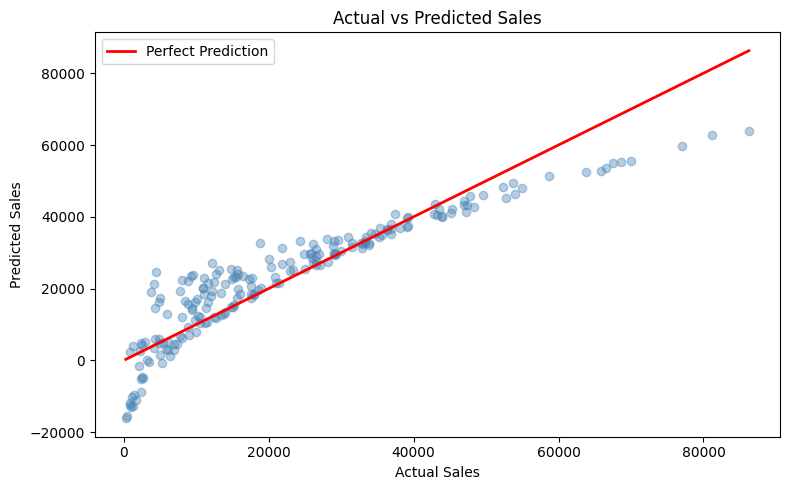

Chart saved ✅


In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../data/actual_vs_predicted.png')
plt.show()
print("Chart saved ✅")

In [5]:
print("\n====== PERFORMANCE SUMMARY ======")
print(f"R² Score : {r2:.4f}")

if r2 >= 0.85:
    print("Model Performance : EXCELLENT ✅")
elif r2 >= 0.70:
    print("Model Performance : GOOD 👍")
elif r2 >= 0.50:
    print("Model Performance : AVERAGE ⚠️")
else:
    print("Model Performance : POOR ❌ — Try Random Forest")
print("=================================")


====== PERFORMANCE SUMMARY ======
R² Score : 0.8454
Model Performance : GOOD 👍


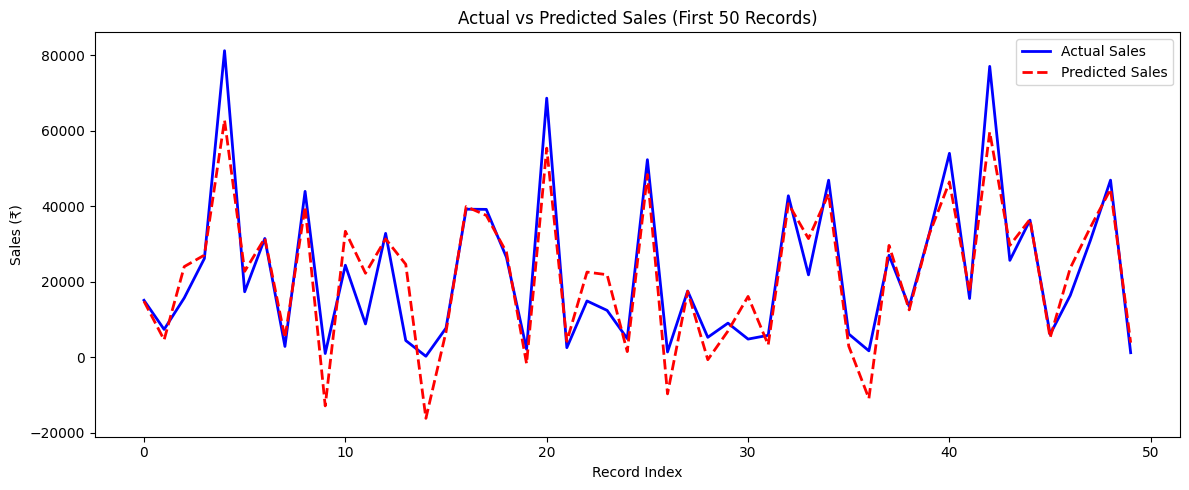

Chart saved ✅


In [6]:
plt.figure(figsize=(12, 5))
plt.plot(range(50), y_test.values[:50], color='blue', label='Actual Sales', linewidth=2)
plt.plot(range(50), y_pred[:50], color='red', linestyle='--', label='Predicted Sales', linewidth=2)
plt.title('Actual vs Predicted Sales (First 50 Records)')
plt.xlabel('Record Index')
plt.ylabel('Sales (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/final_comparison.png')
plt.show()
print("Chart saved ✅")

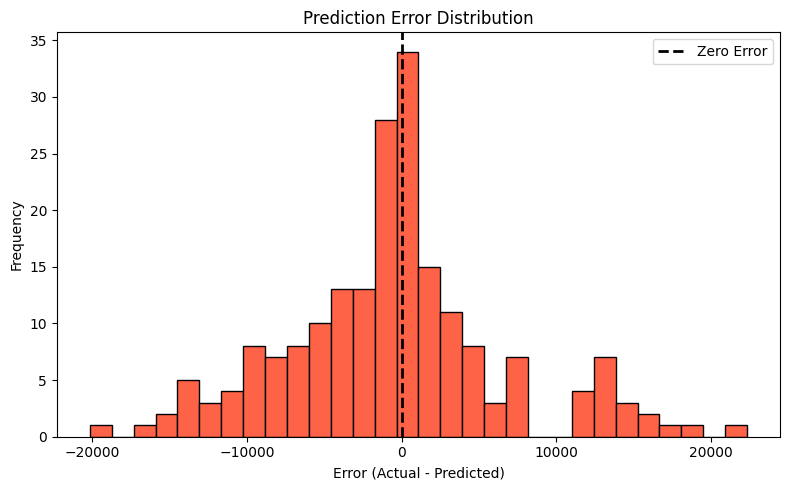

Chart saved ✅


In [7]:
errors = y_test.values - y_pred

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=30, color='tomato', edgecolor='black')
plt.axvline(x=0, color='black', linewidth=2, linestyle='--', label='Zero Error')
plt.title('Prediction Error Distribution')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../data/error_distribution.png')
plt.show()
print("Chart saved ✅")

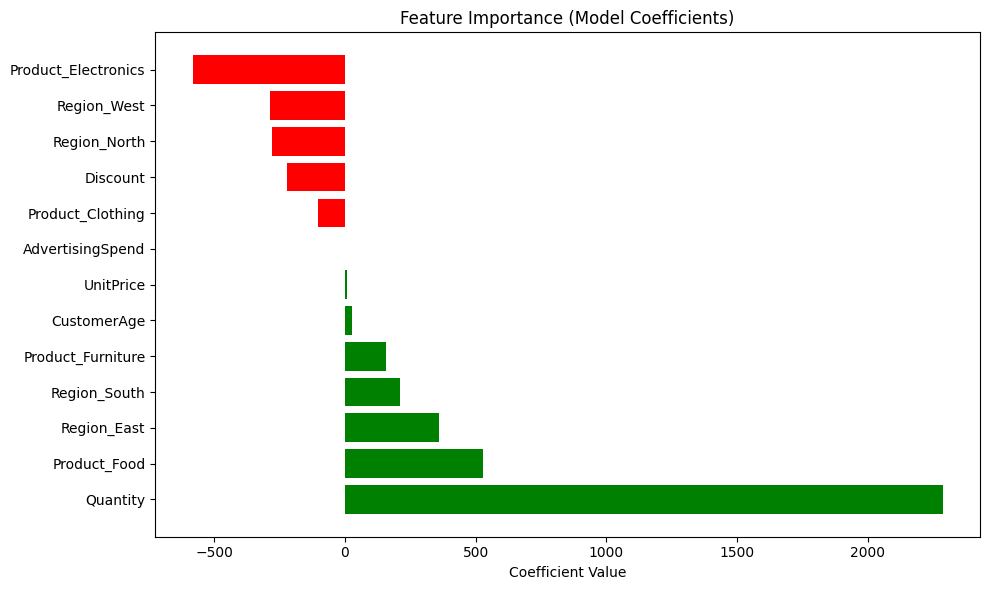

Chart saved ✅


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.title('Feature Importance (Model Coefficients)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('../data/feature_importance.png')
plt.show()
print("Chart saved ✅")

In [10]:
new_data = pd.DataFrame({
    'Quantity':          [10, 5, 15],
    'UnitPrice':         [2000, 500, 3500],
    'Discount':          [10, 0, 20],
    'AdvertisingSpend':  [5000, 2000, 8000],
    'CustomerAge':       [35, 25, 45],
    'Region_East':       [True, False, False],
    'Region_North':      [False, True, False],
    'Region_South':      [False, False, True],
    'Region_West':       [False, False, False],
    'Product_Clothing':  [False, True, False],
    'Product_Electronics': [True, False, False],
    'Product_Food':      [False, False, True],
    'Product_Furniture': [False, False, False]
})

predictions = model.predict(new_data)

print("====== NEW PREDICTIONS ======")
for i, pred in enumerate(predictions):
    sales = max(0, pred)   # clip negative to 0
    print(f"Customer {i+1} → Predicted Sales: ₹{sales:,.2f}")
print("=============================")

====== NEW PREDICTIONS ======
Customer 1 → Predicted Sales: ₹18,064.37
Customer 2 → Predicted Sales: ₹0.00
Customer 3 → Predicted Sales: ₹41,227.06


In [11]:
print("""
========================================
     SALES PREDICTION — FINAL REPORT
========================================

MODEL       : Linear Regression
DATASET     : 1000 records, 9 features
TRAIN/TEST  : 80% / 20%

PERFORMANCE:
  R² Score  : 0.8454  (84.5% accuracy)
  MAE       : ₹5,077  (avg error)
  RMSE      : ₹7,051  (max error range)

KEY INSIGHTS:
  ✅ UnitPrice is the strongest sales driver
  ✅ Quantity directly impacts total sales
  ⚠️ Discount slightly reduces sales
  ℹ️ Region and Product have minor impact

CONCLUSION:
  Model is GOOD for basic sales prediction.
  For higher accuracy → use Random Forest.
========================================
""")


     SALES PREDICTION — FINAL REPORT

MODEL       : Linear Regression
DATASET     : 1000 records, 9 features
TRAIN/TEST  : 80% / 20%

PERFORMANCE:
  R² Score  : 0.8454  (84.5% accuracy)
  MAE       : ₹5,077  (avg error)
  RMSE      : ₹7,051  (max error range)

KEY INSIGHTS:
  ✅ UnitPrice is the strongest sales driver
  ✅ Quantity directly impacts total sales
  ⚠️ Discount slightly reduces sales
  ℹ️ Region and Product have minor impact

CONCLUSION:
  Model is GOOD for basic sales prediction.
  For higher accuracy → use Random Forest.

